In [78]:
#Data Sanity
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv("Data_Sheet_Surface_Water.csv")

In [79]:
#Unit and detection limit handling
df.replace(["ND", "-", "<1"], np.nan, inplace=True)

for col in df.columns:
    if col not in ["Site", "Year"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

C:\Users\jaswa\AppData\Local\Temp\ipykernel_6984\564103238.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(["ND", "-", "<1"], np.nan, inplace=True)


In [80]:
#save the clean dataset
df.to_csv("surface_clean.csv", index=False)


In [81]:
#WQI COMPUTATION
import pandas as pd
import numpy as np
df = pd.read_csv("surface_clean.csv")


In [82]:
#Standards and Weights(NSF Style)
PARAMS = {
    "pH": (7.0, 8.5, 0.11),
    "DO": (14.6, 5.0, 0.17),
    "BOD": (0.0, 3.0, 0.11),
    "Turbidity": (0.0, 5.0, 0.08),
    "Nitrate": (0.0, 45.0, 0.10),
    #"TDS": (0.0, 500.0, 0.07),
}

In [83]:
#Sub Index + WQI
def qi(val, ideal, std):
    if pd.isna(val): return np.nan
    if val <= ideal: return 100
    return max(0, 100 * (std - val) / (std - ideal))

In [84]:
def compute_wqi(row):
    s, w = 0, 0
    for p, (ideal, std, wt) in PARAMS.items():
        if p in row and not pd.isna(row[p]):
            s += qi(row[p], ideal, std) * wt
            w += wt
    return s / w if w > 0 else np.nan


In [85]:
df["WQI"] = df.apply(compute_wqi, axis=1)

In [86]:
#CLASS ASSIGNMENT
def wqi_class(x):
    if x >= 90: return "Excellent"
    if x >= 70: return "Good"
    if x >= 50: return "Medium"
    if x >= 25: return "Poor"
    return "Very Poor"

df["WQI_Class"] = df["WQI"].apply(wqi_class)

In [87]:
df.to_csv("surface_wqi.csv", index=False)

In [88]:
df.head(5)

,Site,Year,pH,Odour,Turbidity,Conductivity,Chloride (ppm),Sulphates(ppm),Iron (ppm),COD(ppm),...,Lead(ppm),Ammonia(ppm),Nitrate(ppm),Fluorides(ppm),Phosphates(ppm),Total Bacterial Count (cfu/ml),Total Fungal Count (cfu/ml),Pesticide (µg/l),WQI,WQI_Class
0,Karan Lake (Site 1) (Surface Water),2016,6.70,NaN,4.30,482,19.0,75.0,16.60,32.1,...,NaN,0.3,9.0,NaN,NaN,500,NaN,NaN,63.789474,Medium
1,Karan Lake (Site 1) (Surface Water),2017,6.80,NaN,5.80,445,19.0,71.0,16.00,34.2,...,NaN,0.3,9.0,NaN,NaN,500,NaN,NaN,57.894737,Medium
2,Karan Lake (Site 1) (Surface Water),2018,7.10,NaN,5.80,442,19.7,71.0,15.80,41.9,...,NaN,0.5,11.0,NaN,5.0,500,NaN,NaN,54.035088,Medium
3,Brahma Sarovar(Site 2) Surface Water,2016,7.47,NaN,1.99,582,12.6,85.0,15.05,84.2,...,NaN,0.0,5.0,NaN,NaN,1200,300.0,NaN,65.101754,Medium
4,Brahma Sarovar(Site 2) Surface Water,2017,6.20,NaN,2.30,634,13.0,90.0,13.55,86.2,...,NaN,0.3,15.0,NaN,NaN,1300,300.0,NaN,80.631579,Good


In [89]:
#ML MODELING
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score

In [90]:
df = pd.read_csv("surface_wqi.csv")

In [91]:
features = [
    "pH",
    "DO(ppm)",
    "BOD(ppm)",
    "Turbidity",
    "Nitrate(ppm)",
    #"TDS",
    #"Fecal_Coliform"
]
# Keep only rows with complete X AND y
ml_df = df[features + ["WQI"]].dropna()
X = ml_df[features]
y = ml_df["WQI"]

In [92]:
df["WQI"].isna().sum(), len(df)

(np.int64(0), 42)

In [93]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

In [94]:
rf = RandomForestRegressor(n_estimators=300)
rf.fit(Xtr, ytr)

RandomForestRegressor(n_estimators=300)

In [95]:
#Classification
y_cls = df["WQI_Class"]
clf = RandomForestClassifier(n_estimators=300)
clf.fit(Xtr, y_cls.loc[Xtr.index])

RandomForestClassifier(n_estimators=300)

In [96]:
df.loc[Xte.index, "WQI_Pred"] = rf.predict(Xte)
print("R²:", r2_score(yte, df.loc[Xte.index, "WQI_Pred"]))

R²: 0.8296811552521864


In [97]:
df.to_csv("surface_wqi_pred.csv", index=False)

In [98]:
df.head(4)

,Site,Year,pH,Odour,Turbidity,Conductivity,Chloride (ppm),Sulphates(ppm),Iron (ppm),COD(ppm),...,Ammonia(ppm),Nitrate(ppm),Fluorides(ppm),Phosphates(ppm),Total Bacterial Count (cfu/ml),Total Fungal Count (cfu/ml),Pesticide (µg/l),WQI,WQI_Class,WQI_Pred
0,Karan Lake (Site 1) (Surface Water),2016,6.70,NaN,4.30,482,19.0,75.0,16.60,32.1,...,0.3,9.0,NaN,NaN,500,NaN,NaN,63.789474,Medium,NaN
1,Karan Lake (Site 1) (Surface Water),2017,6.80,NaN,5.80,445,19.0,71.0,16.00,34.2,...,0.3,9.0,NaN,NaN,500,NaN,NaN,57.894737,Medium,NaN
2,Karan Lake (Site 1) (Surface Water),2018,7.10,NaN,5.80,442,19.7,71.0,15.80,41.9,...,0.5,11.0,NaN,5.0,500,NaN,NaN,54.035088,Medium,NaN
3,Brahma Sarovar(Site 2) Surface Water,2016,7.47,NaN,1.99,582,12.6,85.0,15.05,84.2,...,0.0,5.0,NaN,NaN,1200,300.0,NaN,65.101754,Medium,NaN


In [99]:
df["WQI"].isna().sum()

np.int64(0)

In [100]:
df[df["WQI"].isna()]

,Site,Year,pH,Odour,Turbidity,Conductivity,Chloride (ppm),Sulphates(ppm),Iron (ppm),COD(ppm),...,Ammonia(ppm),Nitrate(ppm),Fluorides(ppm),Phosphates(ppm),Total Bacterial Count (cfu/ml),Total Fungal Count (cfu/ml),Pesticide (µg/l),WQI,WQI_Class,WQI_Pred


In [101]:
df_ml = df.dropna(subset=["WQI"]).copy()

In [102]:
X = df_ml[features]
y = df_ml["WQI"]

In [103]:
X.isna().sum()

pH              0
DO(ppm)         0
BOD(ppm)        0
Turbidity       0
Nitrate(ppm)    0
dtype: int64

In [104]:
df.head(6)

,Site,Year,pH,Odour,Turbidity,Conductivity,Chloride (ppm),Sulphates(ppm),Iron (ppm),COD(ppm),...,Ammonia(ppm),Nitrate(ppm),Fluorides(ppm),Phosphates(ppm),Total Bacterial Count (cfu/ml),Total Fungal Count (cfu/ml),Pesticide (µg/l),WQI,WQI_Class,WQI_Pred
0,Karan Lake (Site 1) (Surface Water),2016,6.70,NaN,4.30,482,19.0,75.0,16.60,32.1,...,0.3,9.0,NaN,NaN,500,NaN,NaN,63.789474,Medium,NaN
1,Karan Lake (Site 1) (Surface Water),2017,6.80,NaN,5.80,445,19.0,71.0,16.00,34.2,...,0.3,9.0,NaN,NaN,500,NaN,NaN,57.894737,Medium,NaN
2,Karan Lake (Site 1) (Surface Water),2018,7.10,NaN,5.80,442,19.7,71.0,15.80,41.9,...,0.5,11.0,NaN,5.0,500,NaN,NaN,54.035088,Medium,NaN
3,Brahma Sarovar(Site 2) Surface Water,2016,7.47,NaN,1.99,582,12.6,85.0,15.05,84.2,...,0.0,5.0,NaN,NaN,1200,300.0,NaN,65.101754,Medium,NaN
4,Brahma Sarovar(Site 2) Surface Water,2017,6.20,NaN,2.30,634,13.0,90.0,13.55,86.2,...,0.3,15.0,NaN,NaN,1300,300.0,NaN,80.631579,Good,68.434316
5,Brahma Sarovar(Site 2) Surface Water,2018,6.17,NaN,3.01,642,13.2,95.0,17.55,89.8,...,0.4,16.0,NaN,NaN,1500,300.0,NaN,74.652632,Good,NaN


In [105]:
#SPATIAL INTELLIGENCE
import pandas as pd
df = pd.read_csv("surface_wqi_pred.csv")

In [106]:
#hotspot resistance
df["Hotspot"] = df["WQI"] < 50

In [107]:
#If no population data exists
df["Exposure_Proxy"] = 1  # equal exposure assumption
df["Priority_Score"] = (100 - df["WQI"]) * df["Exposure_Proxy"]

In [108]:
#rename propely
df.rename(columns={"Priority_Score": "Priority_Index"}, inplace=True)

In [109]:
print(df.columns)

Index(['Site', 'Year', 'pH', 'Odour', 'Turbidity', 'Conductivity',
       'Chloride (ppm)', 'Sulphates(ppm)', 'Iron (ppm)', 'COD(ppm)',
       'BOD(ppm)', 'DO(ppm)', 'Lead(ppm)', 'Ammonia(ppm)', 'Nitrate(ppm)',
       'Fluorides(ppm)', 'Phosphates(ppm)', 'Total Bacterial Count (cfu/ml)',
       'Total Fungal Count (cfu/ml)', 'Pesticide (µg/l)', 'WQI', 'WQI_Class',
       'WQI_Pred', 'Hotspot', 'Exposure_Proxy', 'Priority_Index'],
      dtype='object')


In [110]:
#priority score
df["Priority_Score"] = (100 - df["WQI"]) * df["Exposure_Proxy"]

In [111]:
#save the output
df.to_csv("surface_spatial_scores.csv", index=False)

In [112]:
df.head(4)

,Site,Year,pH,Odour,Turbidity,Conductivity,Chloride (ppm),Sulphates(ppm),Iron (ppm),COD(ppm),...,Total Bacterial Count (cfu/ml),Total Fungal Count (cfu/ml),Pesticide (µg/l),WQI,WQI_Class,WQI_Pred,Hotspot,Exposure_Proxy,Priority_Index,Priority_Score
0,Karan Lake (Site 1) (Surface Water),2016,6.70,NaN,4.30,482,19.0,75.0,16.60,32.1,...,500,NaN,NaN,63.789474,Medium,NaN,False,1,36.210526,36.210526
1,Karan Lake (Site 1) (Surface Water),2017,6.80,NaN,5.80,445,19.0,71.0,16.00,34.2,...,500,NaN,NaN,57.894737,Medium,NaN,False,1,42.105263,42.105263
2,Karan Lake (Site 1) (Surface Water),2018,7.10,NaN,5.80,442,19.7,71.0,15.80,41.9,...,500,NaN,NaN,54.035088,Medium,NaN,False,1,45.964912,45.964912
3,Brahma Sarovar(Site 2) Surface Water,2016,7.47,NaN,1.99,582,12.6,85.0,15.05,84.2,...,1200,300.0,NaN,65.101754,Medium,NaN,False,1,34.898246,34.898246


In [113]:
#HEALTH RISK ABSTRACTION

In [114]:
import pandas as pd
df = pd.read_csv("surface_spatial_scores.csv")

In [115]:
def relative_risk(row):
    if row["WQI"] < 25: return "High"
    if row["WQI"] < 50: return "Moderate"
    return "Low"

In [116]:
df["Relative_Health_Risk"] = df.apply(relative_risk, axis=1)

In [117]:
df.to_csv("surface_relative_risk.csv", index=False)

In [118]:
#ALERTS

In [119]:
import pandas as pd
df = pd.read_csv("surface_relative_risk.csv")

In [120]:
def alert(row):
    if row["WQI"] < 25: return "CRITICAL"
    if row["WQI"] < 50: return "WARNING"
    return "NORMAL"

In [121]:
df["Alert_Level"] = df.apply(alert, axis=1)

In [122]:
df.to_csv("surface_alerts.csv", index=False)

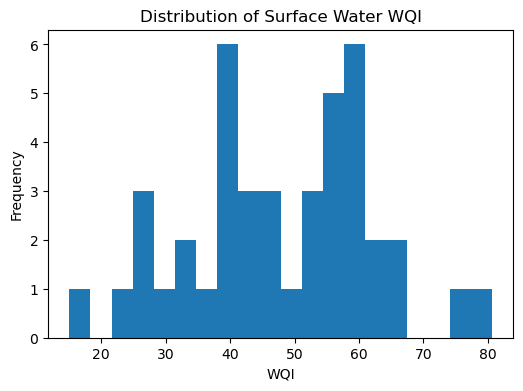

In [123]:
#PLOTTING
#1. DATA SANITY
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(6,4))
plt.hist(df["WQI"], bins=20)
plt.xlabel("WQI")
plt.ylabel("Frequency")
plt.title("Distribution of Surface Water WQI")
plt.show()


In [124]:
#Actual vs Predicted WQI
from sklearn.model_selection import train_test_split

PARAMS = {
    "pH": (7.0, 8.5, 0.11),
    "DO(ppm)": (14.6, 5.0, 0.17),
    "BOD(ppm)": (0.0, 3.0, 0.11),
    "Turbidity": (0.0, 5.0, 0.08),
    "Nitrate(ppm)": (0.0, 45.0, 0.10),
    #"TDS": (0.0, 500.0, 0.07),
}
features = list(PARAMS.keys())
X = df[features]
y = df["WQI"]

In [125]:
print(X.isna().sum())
print(y.isna().sum())

pH              0
DO(ppm)         0
BOD(ppm)        0
Turbidity       0
Nitrate(ppm)    0
dtype: int64
0


In [126]:
X = X.fillna(X.median())
y = y.dropna()
X = X.loc[y.index]

In [127]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

Xtr, Xte, ytr, yte = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(Xtr, ytr)
yp = rf.predict(Xte)

In [128]:
# PARAMS was a dict used for WQI calculation
features = list(PARAMS.keys())

# Select features and target
X = df[features]
y = df["WQI"]

In [129]:
# Check
print("X NaNs:\n", X.isna().sum())
print("y NaNs:", y.isna().sum())

# Fix
X = X.fillna(X.median())

y = y.dropna()
X = X.loc[y.index]

X NaNs:
 pH              0
DO(ppm)         0
BOD(ppm)        0
Turbidity       0
Nitrate(ppm)    0
dtype: int64
y NaNs: 0


In [130]:
from sklearn.model_selection import train_test_split

Xtr, Xte, ytr, yte = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [131]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(Xtr, ytr)

RandomForestRegressor(n_estimators=300, random_state=42)

In [132]:
yp = rf.predict(Xte)

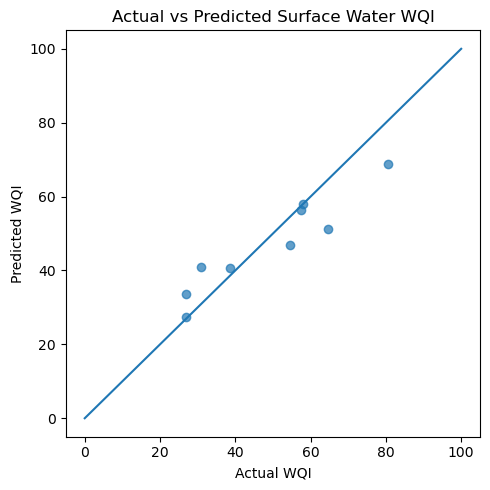

In [133]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(5, 5))

plt.scatter(yte, yp, alpha=0.7)
plt.plot([0, 100], [0, 100])  # ideal prediction line

plt.xlabel("Actual WQI")
plt.ylabel("Predicted WQI")
plt.title("Actual vs Predicted Surface Water WQI")

plt.tight_layout()
plt.show()

In [134]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(yte, yp)
rmse = np.sqrt(mean_squared_error(yte, yp))

print(f"R² = {r2:.2f}")
print(f"RMSE = {rmse:.2f}")

R² = 0.81
RMSE = 7.67


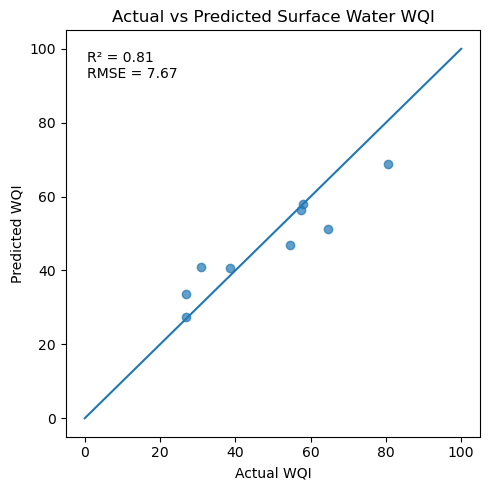

In [135]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

r2 = r2_score(yte, yp)
rmse = np.sqrt(mean_squared_error(yte, yp))

plt.figure(figsize=(5,5))

plt.scatter(yte, yp, alpha=0.7)
plt.plot([0, 100], [0, 100])

plt.xlabel("Actual WQI")
plt.ylabel("Predicted WQI")
plt.title("Actual vs Predicted Surface Water WQI")

# Annotate metrics
plt.text(
    0.05, 0.95,
    f"R² = {r2:.2f}\nRMSE = {rmse:.2f}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.tight_layout()
plt.show()

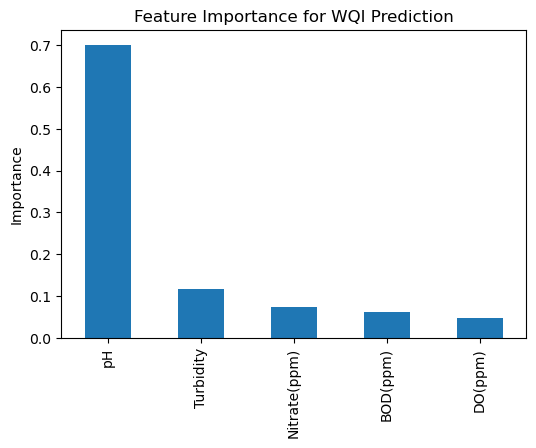

In [136]:
#Feature Importance
import pandas as pd

imp = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(6,4))
imp.plot(kind="bar")
plt.ylabel("Importance")
plt.title("Feature Importance for WQI Prediction")
plt.show()

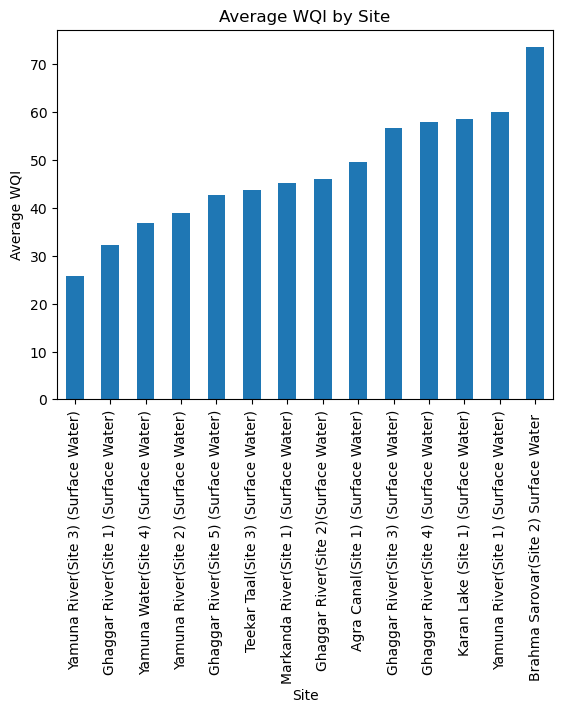

In [137]:
#Which city is most polluted?
#SITE-WISE WQI COMPARISON
site_wqi = df.groupby('Site')['WQI'].mean().sort_values()

plt.figure()
site_wqi.plot(kind='bar')
plt.xlabel('Site')
plt.ylabel('Average WQI')
plt.title('Average WQI by Site')
plt.show()

In [138]:
print(df.columns)

Index(['Site', 'Year', 'pH', 'Odour', 'Turbidity', 'Conductivity',
       'Chloride (ppm)', 'Sulphates(ppm)', 'Iron (ppm)', 'COD(ppm)',
       'BOD(ppm)', 'DO(ppm)', 'Lead(ppm)', 'Ammonia(ppm)', 'Nitrate(ppm)',
       'Fluorides(ppm)', 'Phosphates(ppm)', 'Total Bacterial Count (cfu/ml)',
       'Total Fungal Count (cfu/ml)', 'Pesticide (µg/l)', 'WQI', 'WQI_Class',
       'WQI_Pred', 'Hotspot', 'Exposure_Proxy', 'Priority_Index',
       'Priority_Score', 'Relative_Health_Risk', 'Alert_Level'],
      dtype='object')


In [139]:
#HEATMAP PLOTTING
qi_cols = [
    "pH",
    "DO(ppm)",
    "BOD(ppm)",
    "Turbidity",
    "Nitrate(ppm)",
    #"TDS",
]

heatmap_data = df[qi_cols]

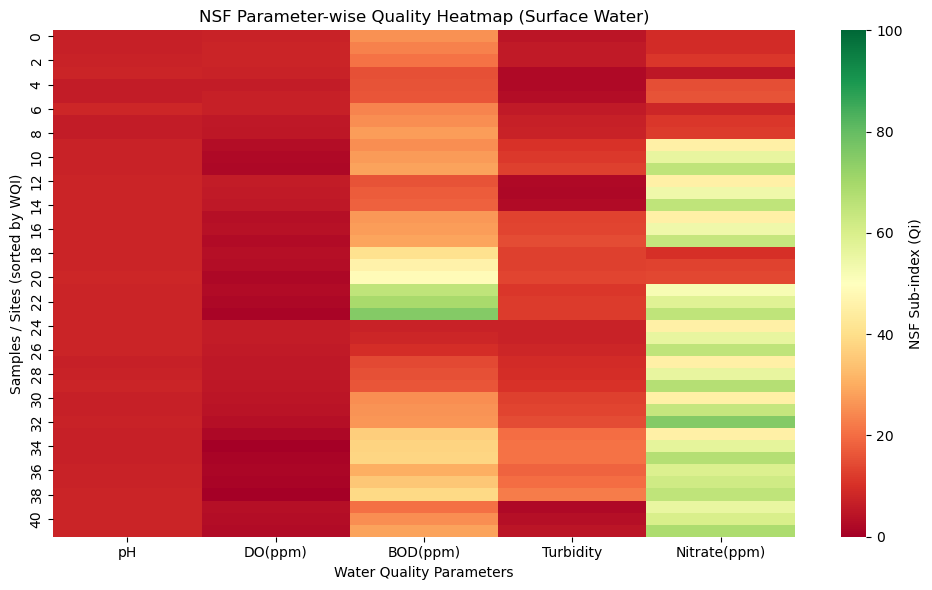

In [140]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(10, 6))

sns.heatmap(
    heatmap_data,
    cmap="RdYlGn",     # red = bad quality, green = good
    vmin=0,
    vmax=100,
    cbar_kws={"label": "NSF Sub-index (Qi)"}
)

plt.title("NSF Parameter-wise Quality Heatmap (Surface Water)")
plt.xlabel("Water Quality Parameters")
plt.ylabel("Samples / Sites (sorted by WQI)")
plt.tight_layout()
plt.show()

In [141]:
### Final Model Evaluation & Interpretation

In [142]:
X        # feature matrix (parameters)
y  # target WQI (numeric)

0     63.789474
1     57.894737
2     54.035088
3     65.101754
4     80.631579
5     74.652632
6     15.052632
7     57.894737
8     57.894737
9     52.491228
10    50.175439
11    46.315789
12    63.403509
13    64.701754
14    51.929825
15    41.298246
16    38.596491
17    37.052632
18    27.017544
19    27.017544
20    23.157895
21    38.210526
22    38.596491
23    33.964912
24    38.596491
25    30.877193
26    27.017544
27    56.736842
28    42.456140
29    38.596491
30    57.508772
31    56.736842
32    55.964912
33    57.894737
34    57.894737
35    57.894737
36    44.771930
37    42.456140
38    40.526316
39    54.526316
40    47.368421
41    33.614035
Name: WQI, dtype: float64

In [143]:
#CROSS VALIDATON- K FOLD Validation
from sklearn.model_selection import cross_val_score
import numpy as np

cv_rmse_5 = -cross_val_score(
    rf, X, y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

cv_rmse_10 = -cross_val_score(
    rf, X, y,
    cv=10,
    scoring="neg_root_mean_squared_error"
)

print("5-Fold CV RMSE:", cv_rmse_5.mean())
print("10-Fold CV RMSE:", cv_rmse_10.mean())

5-Fold CV RMSE: 6.4317896361938365
10-Fold CV RMSE: 5.3926567921496495


In [177]:
#REGRESSION METRICS
def nse(y_true, yp):
    return 1 - (
        np.sum((y_true - yp) ** 2) /
        np.sum((y_true - np.mean(y_true)) ** 2)
    )

nse_value = nse(yte.values, yp)

print("NSE:", nse_value)

NSE: 0.8131085151797022


In [145]:
#ENSEMBLE
from sklearn.ensemble import GradientBoostingRegressor, VotingRegressor

gbr = GradientBoostingRegressor(random_state=42)

ensemble = VotingRegressor(
    estimators=[
        ("rf", rf),
        ("gbr", gbr)
    ]
)

ensemble.fit(Xtr, ytr)
y_pred_ens = ensemble.predict(Xte)

In [174]:
from sklearn.metrics import mean_squared_error
rmse_ens = np.sqrt(mean_squared_error(yte, y_pred_ens))
r2 = r2_score(yte, y_pred_ens)
nse = nse(yte.values, y_pred_ens)

print("Ensemble R²:", r2)
print("Ensemble NSE:", nse)
print("Ensemble RMSE:", rmse_ens)

Ensemble R²: 0.8766298058579796
Ensemble NSE: 0.8766298058579796
Ensemble RMSE: 6.230313994251207


In [147]:
#CLASSIFICATION METRICS
y_true_cls = df.loc[Xte.index, "WQI_Class"]
yp_cls = clf.predict(Xte)

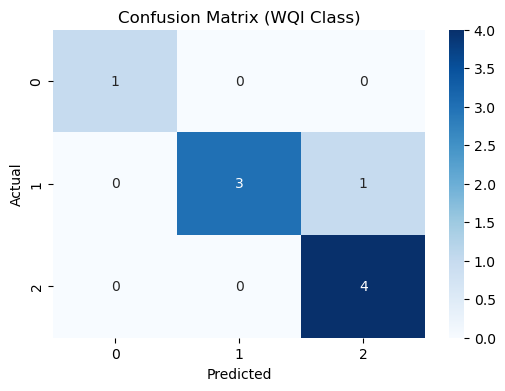

Accuracy: 0.8888888888888888
F1-score: 0.8871252204585538
MCC: 0.8299751174897799
              precision    recall  f1-score   support

        Good       1.00      1.00      1.00         1
      Medium       1.00      0.75      0.86         4
        Poor       0.80      1.00      0.89         4

    accuracy                           0.89         9
   macro avg       0.93      0.92      0.92         9
weighted avg       0.91      0.89      0.89         9



In [148]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    f1_score,
    matthews_corrcoef,
    classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_cls, yp_cls)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (WQI Class)")
plt.show()

print("Accuracy:", accuracy_score(y_true_cls, yp_cls))
print("F1-score:", f1_score(y_true_cls, yp_cls, average="weighted"))
print("MCC:", matthews_corrcoef(y_true_cls, yp_cls))

print(classification_report(y_true_cls, yp_cls))

In [149]:
print(df.columns)

Index(['Site', 'Year', 'pH', 'Odour', 'Turbidity', 'Conductivity',
       'Chloride (ppm)', 'Sulphates(ppm)', 'Iron (ppm)', 'COD(ppm)',
       'BOD(ppm)', 'DO(ppm)', 'Lead(ppm)', 'Ammonia(ppm)', 'Nitrate(ppm)',
       'Fluorides(ppm)', 'Phosphates(ppm)', 'Total Bacterial Count (cfu/ml)',
       'Total Fungal Count (cfu/ml)', 'Pesticide (µg/l)', 'WQI', 'WQI_Class',
       'WQI_Pred', 'Hotspot', 'Exposure_Proxy', 'Priority_Index',
       'Priority_Score', 'Relative_Health_Risk', 'Alert_Level'],
      dtype='object')


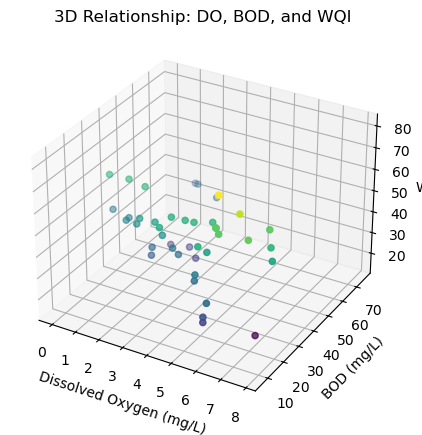

In [150]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df["DO(ppm)"],
    df["BOD(ppm)"],
    df["WQI"],
    c=df["WQI"],
    cmap="viridis"
)

ax.set_xlabel("Dissolved Oxygen (mg/L)")
ax.set_ylabel("BOD (mg/L)")
ax.set_zlabel("WQI")
ax.set_title("3D Relationship: DO, BOD, and WQI")

plt.show()
# It shows nonlinear interaction

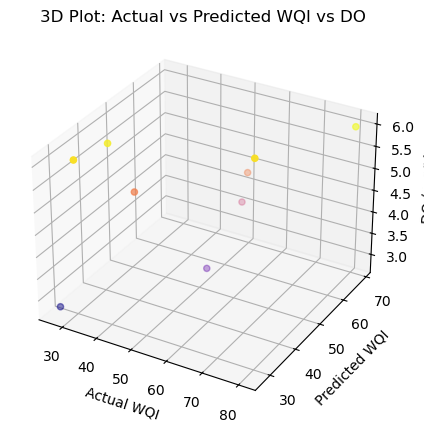

In [151]:
#Actual vs Predicted WQI
fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    yte,
    yp,
    df.loc[Xte.index, "DO(ppm)"],
    c=df.loc[Xte.index, "DO(ppm)"],
    cmap="plasma"
)

ax.set_xlabel("Actual WQI")
ax.set_ylabel("Predicted WQI")
ax.set_zlabel("DO (mg/L)")
ax.set_title("3D Plot: Actual vs Predicted WQI vs DO")

plt.show()
#This shows model behavior, not accuracy.

In [152]:
y_true_cls = df.loc[Xte.index, "WQI_Class"]

In [158]:
#CLASSIFICATION METRICS (TABULAR FORMAT)

In [153]:
#Function to compute metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)

def classification_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted"),
        "Recall": recall_score(y_true, y_pred, average="weighted"),
        "F1-score": f1_score(y_true, y_pred, average="weighted"),
        "MCC": matthews_corrcoef(y_true, y_pred)
    }

In [160]:
#Collect results from each model
results = []

# Random Forest
results.append({
    "Model": "Random Forest",
    **classification_metrics(y_true_cls, clf.predict(Xte))
})

# SVM
#results.append({
 #   "Model": "SVM",
  #  **classification_metrics(y_true_cls, clf_svm.predict(Xte))
#})

# Logistic Regression
results.append({
    "Model": "Logistic Regression",
    **classification_metrics(y_true_cls, clf.predict(Xte))
})

In [162]:
#Convert to DataFrame
import pandas as pd

clf_results_df = pd.DataFrame(results)
clf_results_df

,Model,Accuracy,Precision,Recall,F1-score,MCC
0,Random Forest,0.888889,0.911111,0.888889,0.887125,0.829975
1,Logistic Regression,0.888889,0.911111,0.888889,0.887125,0.829975


In [164]:
#round values
clf_results_df.set_index("Model").round(3)

,Accuracy,Precision,Recall,F1-score,MCC
Model,,,,,
Random Forest,0.889,0.911,0.889,0.887,0.83
Logistic Regression,0.889,0.911,0.889,0.887,0.83


In [165]:
#REGRESSION METRICS (TABULAR FORMAT)
y_true=yte

In [166]:
#NSE Function
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

def nse(y_true, y_pred):
    return 1 - (
        np.sum((y_true - y_pred) ** 2) /
        np.sum((y_true - np.mean(y_true)) ** 2)
    )

In [181]:
#Collect Regression Re
reg_results = []

# Random Forest
y_pred_rf = rf.predict(Xte)
reg_results.append({
    "Model": "Random Forest",
    "R2": r2_score(y_true, y_pred_rf),
    "RMSE": np.sqrt(mean_squared_error(y_true, y_pred_rf)),
    "nse": nse(y_true.values, y_pred_rf)
})

# SVR
#y_pred_svr = svr.predict(Xte)
#reg_results.append({
 #   "Model": "SVR",
  #  "R2": r2_score(y_true, y_pred_svr),
   # "RMSE": np.sqrt(mean_squared_error(y_true, y_pred_svr)),
   # "NSE": nse(y_true.values, y_pred_svr)
#})

# Ensemble
y_pred_ens = ensemble.predict(Xte)
reg_results.append({
    "Model": "Ensemble (RF+GB)",
    "R2": r2_score(y_true, y_pred_ens),
    "RMSE": np.sqrt(mean_squared_error(y_true, y_pred_ens)),
    "nse": nse(y_true.values, y_pred_ens)
})

In [182]:
#Convert to data frame
reg_results_df = pd.DataFrame(reg_results)
reg_results_df.set_index("Model").round(3)

,R2,RMSE,nse
Model,,,
Random Forest,0.813,7.668,0.813
Ensemble (RF+GB),0.877,6.230,0.877


In [184]:
clf_results_df.to_csv("sclassification_metrics_summary.csv", index=False)
reg_results_df.to_csv("sregression_metrics_summary.csv", index=False)